# 02 – Modelling: Predicting Survival

> **Project notebooks:** [01 Exploration](01_exploration.ipynb) · [02 Modelling](02_modelling.ipynb) · [03 Improvements](03_improvements.ipynb) · [04 Pipelines](04_pipelines.ipynb)

**Goal of this notebook:** build models that predict who survived, compare them fairly, and make a first Kaggle submission.

**Contents**
1. Setup: load and clean the data
2. Feature engineering
3. Modelling
4. First conclusions
5. Improving the model and submitting to Kaggle
6. Conclusions

## 1. Setup: load and clean the data

Every notebook should run on its own, from top to bottom. So we start by repeating the cleaning steps from [01_exploration](01_exploration.ipynb) in one cell.

> Copying cleaning code between notebooks works, but it is easy to make a mistake when something changes. In [04_pipelines](04_pipelines.ipynb) we will see how real projects avoid this repetition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/train.csv")
data = df.copy()

# Title from the name (Mr, Mrs, Miss, Master, ...); rare titles are grouped together
data["Title"] = data["Name"].str.extract(r",\s*([^\.]+)\.")
data["Title"] = data["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
rare = data["Title"].value_counts()[lambda s: s < 10].index
data["Title"] = data["Title"].replace(rare, "Rare")

# Fill missing values
data["Age"] = data.groupby("Title")["Age"].transform(lambda s: s.fillna(s.median()))
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# New columns
data["HasCabin"] = data["Cabin"].notna().astype(int)
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1

print(f"Rows: {len(data)}, missing values left in the columns we use: "
      f"{data[['Age', 'Embarked', 'Title', 'HasCabin', 'FamilySize']].isna().sum().sum()}")

Rows: 891, missing values left in the columns we use: 0


## 2. Feature engineering

In [2]:
features = ["Pclass", "Sex", "Age", "Fare", "FamilySize", "HasCabin", "Embarked", "Title"]

X = pd.get_dummies(data[features], columns=["Sex", "Embarked", "Title"], drop_first=True)
y = data["Survived"]
X.head()

,Pclass,Age,Fare,FamilySize,HasCabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,22.0,7.2500,2,0,True,False,True,False,True,False,False
1,1,38.0,71.2833,2,1,False,False,False,False,False,True,False
2,3,26.0,7.9250,1,0,False,False,True,True,False,False,False
3,1,35.0,53.1000,2,1,False,False,True,False,False,True,False
4,3,35.0,8.0500,1,0,True,False,True,False,True,False,False


## 3. Modelling

We compare a simple baseline (predict that every woman survives) with two models, using 5‑fold cross‑validation.

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline_acc = accuracy_score(y_test, (X_test["Sex_male"] == 0).astype(int))
print(f"Baseline (all women survive): {baseline_acc:.3f}")

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42),
}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name}: CV accuracy {scores.mean():.3f} ± {scores.std():.3f}")

Baseline (all women survive): 0.777
Logistic Regression: CV accuracy 0.820 ± 0.019
Random Forest: CV accuracy 0.820 ± 0.024


Test accuracy: 0.810

              precision    recall  f1-score   support

        Died       0.82      0.89      0.85       110
    Survived       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



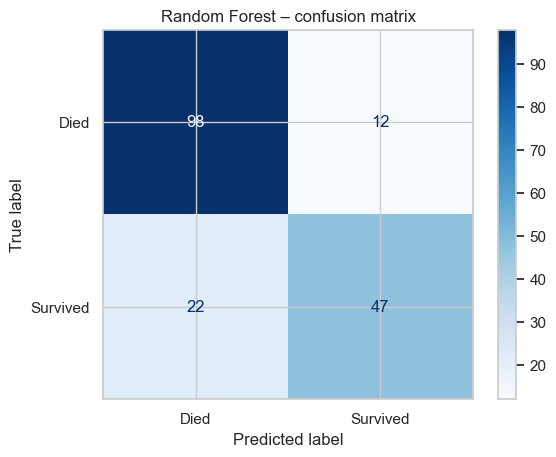

In [4]:
best = models["Random Forest"].fit(X_train, y_train)
pred = best.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, pred):.3f}\n")
print(classification_report(y_test, pred, target_names=["Died", "Survived"]))

ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Died", "Survived"], cmap="Blues")
plt.title("Random Forest – confusion matrix")
plt.show()

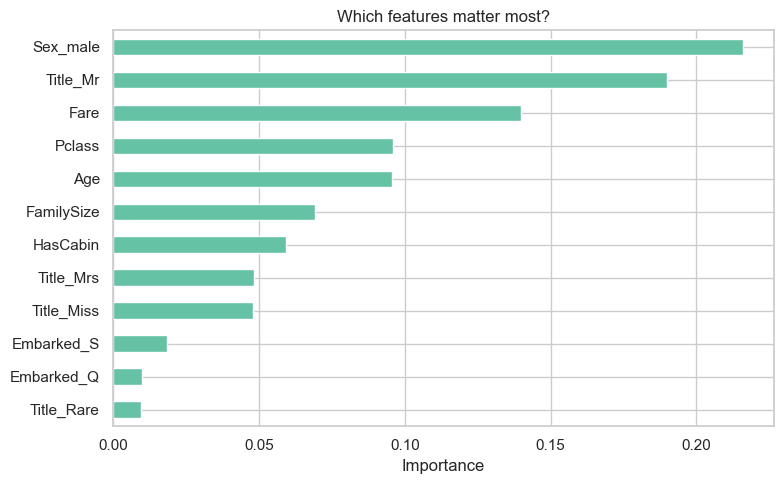

In [5]:
importance = pd.Series(best.feature_importances_, index=X.columns).sort_values()
importance.plot.barh(figsize=(8, 5), title="Which features matter most?")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=120)
plt.show()

## 4. First conclusions

- **Sex** was the strongest predictor of survival: women were roughly 4× more likely to survive than men.
- **Ticket class** mattered: 1st‑class passengers survived at about 63%, 3rd‑class at about 24%.
- **Children** and passengers in **small families** had better chances.
- A Random Forest model reaches about **82% cross‑validated accuracy** (81% on the held‑out test set), beating the simple “all women survive” baseline.

**Next steps** (section 5 below): tune hyper‑parameters, try gradient boosting, and submit predictions for `test.csv` to the Kaggle competition.

## 5. Improving the model and submitting to Kaggle

In this section we:
1. **Tune hyper‑parameters** of the Random Forest with a grid search.
2. **Try gradient boosting** – scikit‑learn's `GradientBoostingClassifier` and `XGBoost`.
3. **Compare** all models with the same 5‑fold cross‑validation.
4. **Predict `test.csv`** with the best model and create a Kaggle submission file.

### 5.1 Hyper‑parameter tuning: Random Forest

`GridSearchCV` tries every combination of the settings below and keeps the one with the best cross‑validated accuracy.
We use `StratifiedKFold` so every fold has the same share of survivors.

In [6]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        "n_estimators": [200, 500],
        "max_depth": [4, 6, 8, None],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.5],
    },
    cv=cv, scoring="accuracy", n_jobs=-1,
)
rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print(f"Best CV accuracy: {rf_grid.best_score_:.3f}")

Best parameters: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 500}
Best CV accuracy: 0.836


### 5.2 Gradient boosting

Gradient boosting builds many small trees one after another, each one correcting the mistakes of the previous ones.
It has more settings than a Random Forest, so for XGBoost we use `RandomizedSearchCV`, which tests a random sample of 40 combinations instead of all of them.

In [7]:
from sklearn.ensemble import GradientBoostingClassifier

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3, 4],
        "subsample": [0.8, 1.0],
    },
    cv=cv, scoring="accuracy", n_jobs=-1,
)
gb_grid.fit(X_train, y_train)

print("Best parameters:", gb_grid.best_params_)
print(f"Best CV accuracy: {gb_grid.best_score_:.3f}")

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best CV accuracy: 0.837


In [8]:
from xgboost import XGBClassifier

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    param_distributions={
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth": [2, 3, 4, 5],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [1, 3, 5],
    },
    n_iter=40, cv=cv, scoring="accuracy", n_jobs=-1, random_state=42,
)
xgb_search.fit(X_train, y_train)

print("Best parameters:", xgb_search.best_params_)
print(f"Best CV accuracy: {xgb_search.best_score_:.3f}")

Best parameters: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Best CV accuracy: 0.834


### 5.3 Model comparison

All models are scored with the same cross‑validation folds on the training split, and on the 20% hold‑out test split they have never seen.

In [9]:
candidates = {
    "Logistic Regression": models["Logistic Regression"],
    "Random Forest (default)": models["Random Forest"],
    "Random Forest (tuned)": rf_grid.best_estimator_,
    "Gradient Boosting (tuned)": gb_grid.best_estimator_,
    "XGBoost (tuned)": xgb_search.best_estimator_,
}

rows = []
for name, model in candidates.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    model.fit(X_train, y_train)
    rows.append({
        "model": name,
        "CV accuracy": cv_scores.mean(),
        "CV std": cv_scores.std(),
        "hold-out accuracy": accuracy_score(y_test, model.predict(X_test)),
    })

results = pd.DataFrame(rows).set_index("model").sort_values("CV accuracy", ascending=False)
results.round(3)

,CV accuracy,CV std,hold-out accuracy
model,,,
Gradient Boosting (tuned),0.837,0.024,0.821
Random Forest (tuned),0.836,0.029,0.799
XGBoost (tuned),0.834,0.020,0.788
Logistic Regression,0.831,0.029,0.844
Random Forest (default),0.824,0.018,0.810


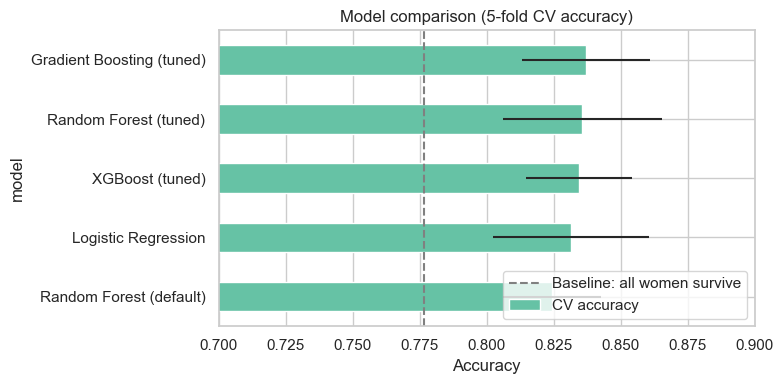

In [10]:
ax = results["CV accuracy"].sort_values().plot.barh(
    xerr=results["CV std"].reindex(results["CV accuracy"].sort_values().index),
    figsize=(8, 4), title="Model comparison (5-fold CV accuracy)",
)
ax.axvline(baseline_acc, color="grey", linestyle="--", label="Baseline: all women survive")
ax.set_xlim(0.7, 0.9)
ax.set_xlabel("Accuracy")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../images/model_comparison.png", dpi=120)
plt.show()

The differences between the models are small (around 1–2 percentage points) and within the spread between folds.
On a dataset of only 891 passengers that is expected: the features we built matter more than the choice of algorithm.
We pick the model with the best **cross‑validated** accuracy, because it is a more reliable estimate than a single 179‑passenger hold‑out set.

In [11]:
best_name = results.index[0]
print(f"Best model: {best_name}")

Best model: Gradient Boosting (tuned)


### 5.4 Preparing `test.csv`

The test file must go through **exactly the same steps** as the training data.
Missing values are filled with statistics learned from the **training** data only (never from the test set), and the dummy columns are aligned with the training columns.
`test.csv` also has one missing `Fare`, which we fill with the median fare of that ticket class.

In [12]:
test_raw = pd.read_csv("../data/test.csv")
print(f"Test rows: {test_raw.shape[0]}")
print(test_raw.isna().sum()[lambda s: s > 0])

common_titles = data["Title"].unique()
title_age_median = data.groupby("Title")["Age"].median()
class_fare_median = df.groupby("Pclass")["Fare"].median()
embarked_mode = df["Embarked"].mode()[0]


def prepare_features(raw):
    """Apply the same cleaning and feature engineering as for the training data."""
    out = raw.copy()
    out["Title"] = out["Name"].str.extract(r",\s*([^\.]+)\.")
    out["Title"] = out["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    out.loc[~out["Title"].isin(common_titles), "Title"] = "Rare"
    out["Age"] = out["Age"].fillna(out["Title"].map(title_age_median))
    out["Fare"] = out["Fare"].fillna(out["Pclass"].map(class_fare_median))
    out["Embarked"] = out["Embarked"].fillna(embarked_mode)
    out["HasCabin"] = out["Cabin"].notna().astype(int)
    out["FamilySize"] = out["SibSp"] + out["Parch"] + 1
    encoded = pd.get_dummies(out[features], columns=["Sex", "Embarked", "Title"], drop_first=True)
    return encoded.reindex(columns=X.columns, fill_value=0)


X_submit = prepare_features(test_raw)
assert X_submit.isna().sum().sum() == 0
assert (prepare_features(df) == X).all().all()  # sanity check: same result as section 2 on the training data
X_submit.head()

Test rows: 418
Age       86
Fare       1
Cabin    327
dtype: int64


,Pclass,Age,Fare,FamilySize,HasCabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,34.5,7.8292,1,0,True,True,False,False,True,False,False
1,3,47.0,7.0000,2,0,False,False,True,False,False,True,False
2,2,62.0,9.6875,1,0,True,True,False,False,True,False,False
3,3,27.0,8.6625,1,0,True,False,True,False,True,False,False
4,3,22.0,12.2875,3,0,False,False,True,False,False,True,False


### 5.5 Final model and Kaggle submission

Now that the model is chosen, we retrain it on **all 891** training passengers (more data = a slightly better model) and predict the 418 test passengers.

In [13]:
from sklearn.base import clone
from pathlib import Path

final_model = clone(candidates[best_name]).fit(X, y)

submission = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"],
    "Survived": final_model.predict(X_submit).astype(int),
})

Path("../submissions").mkdir(exist_ok=True)
submission.to_csv("../submissions/submission.csv", index=False)

print(f"Saved {len(submission)} predictions to submissions/submission.csv")
print(f"Predicted survival rate: {submission['Survived'].mean():.1%} (training data: {y.mean():.1%})")
submission.head()

Saved 418 predictions to submissions/submission.csv
Predicted survival rate: 35.9% (training data: 38.4%)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


**How to submit:** go to the [Titanic competition page](https://www.kaggle.com/competitions/titanic/submissions), click **Submit Prediction**, upload `submissions/submission.csv`, and Kaggle shows your public leaderboard score.

Kaggle scores the submission on passengers our model has never seen, so expect the leaderboard score to be a few points below the cross‑validated accuracy. Around 0.77–0.79 is typical for this kind of model.

| Model | Kaggle public score |
|---|---|
| Gradient Boosting (tuned) | **0.77511** |

The leaderboard score (77.5%) is about 6 points below the cross‑validated accuracy (83.7%), which suggests the model still overfits the small training set slightly. The ideas in section 6 (ticket/family groups, ensembles) are the natural next things to try.

## 6. Conclusions

- **Feature engineering beat algorithm choice.** Title, sex, class and family size carry most of the signal; tuning and gradient boosting changed accuracy by only 1–2 percentage points.
- **Tuning helps a little.** Limiting tree depth and leaf size stops the models from memorising the small training set.
- **The evaluation was honest.** Test data was prepared using only statistics from the training data, and models were compared with the same cross‑validation folds.

**Ideas to go further** (tried in the next notebook, [03_improvements](03_improvements.ipynb)): group passengers who share a ticket or surname (families often survived or died together), combine several models in an ensemble, or add features from the `Ticket` and `Cabin` deck letter.